# SMS Spam Classification: Decision Tree Rule Extraction

This notebook:
1. Loads cached tag features from the SMS spam dataset
2. Trains a shallow decision tree on the **entire dataset** (no train/test split)
3. Extracts interpretable rules and selects high-purity rules with good coverage

## 1. Setup and Imports

In [1]:
import json
import hashlib
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict, Tuple
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

## 2. Configuration

In [2]:
# Paths
DATA_DIR = Path('../input/sms_spam')
DATA_FILE = DATA_DIR / 'SMSSpamCollection'
CACHE_FILE = DATA_DIR / 'tags_cache.json'

# Class names
CLASS_NAMES = ['ham', 'spam']

# Reserved column names (not valid tags)
RESERVED_COLUMNS = {'message', 'label', 'image_path', 'index'}

## 3. Load SMS Dataset

In [3]:
def load_sms_dataset() -> Tuple[List[str], List[int]]:
    """Load SMS messages and labels from the dataset."""
    messages = []
    labels = []
    
    with open(DATA_FILE, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t', 1)
            if len(parts) == 2:
                label_str, message = parts
                messages.append(message)
                labels.append(1 if label_str.lower() == 'spam' else 0)
    
    return messages, labels


messages, labels = load_sms_dataset()
print(f'Loaded {len(messages)} messages')
print(f'  Spam: {sum(labels)} ({sum(labels)/len(labels)*100:.1f}%)')
print(f'  Ham: {len(labels) - sum(labels)} ({(len(labels)-sum(labels))/len(labels)*100:.1f}%)')

Loaded 5574 messages
  Spam: 747 (13.4%)
  Ham: 4827 (86.6%)


## 4. Load Cached Tags

In [4]:
def get_message_key(message: str) -> str:
    """Create a unique key for a message (hash of first 100 chars + length)."""
    content = f"{message[:100]}_{len(message)}"
    return hashlib.md5(content.encode()).hexdigest()


# Load cached tags
with open(CACHE_FILE, 'r') as f:
    tags_cache = json.load(f)

print(f'Loaded {len(tags_cache)} cached tag entries')

# Show sample
sample_key = get_message_key(messages[0])
print(f'\nSample message: "{messages[0][:60]}..."')
print(f'Sample tags: {tags_cache.get(sample_key, [])}')

Loaded 5148 cached tag entries

Sample message: "Go until jurong point, crazy.. Available only in bugis n gre..."
Sample tags: ['location_reference', 'not_clear', 'informal_style']


## 5. Convert to Tabular Dataset

In [5]:
def is_valid_tag(tag: str) -> bool:
    """Check if a tag is valid (not message content or reserved)."""
    if not tag or not isinstance(tag, str):
        return False
    tag = tag.strip()
    if len(tag) > 50 or len(tag) == 0:
        return False
    if '  ' in tag or tag.count(' ') > 3:
        return False
    if tag[0].isupper() and ' ' in tag:
        return False
    # Check reserved names
    normalized = tag.strip().lower().replace(' ', '_').replace('-', '_')
    normalized = ''.join(c for c in normalized if c.isalnum() or c == '_')
    if normalized in RESERVED_COLUMNS:
        return False
    return True


def normalize_tag(tag: str) -> str:
    """Normalize a tag to lowercase with underscores."""
    tag = tag.strip().lower()
    tag = tag.replace(' ', '_').replace('-', '_')
    tag = ''.join(c for c in tag if c.isalnum() or c == '_')
    return tag


def create_tabular_dataset(messages: List[str], 
                           labels: List[int], 
                           tags_cache: Dict[str, List[str]]) -> Tuple[pd.DataFrame, List[str]]:
    """Convert SMS dataset to tabular format using extracted tags as boolean features."""
    # Collect all unique valid tags
    all_tags = set()
    invalid_count = 0
    for tags in tags_cache.values():
        for tag in tags:
            if is_valid_tag(tag):
                all_tags.add(normalize_tag(tag))
            else:
                invalid_count += 1
    
    all_tags = sorted(list(all_tags))
    print(f'Total unique valid tags: {len(all_tags)}')
    print(f'Invalid tags filtered out: {invalid_count}')
    
    # Create feature matrix
    data = []
    for msg, label in zip(messages, labels):
        msg_key = get_message_key(msg)
        raw_tags = tags_cache.get(msg_key, [])
        msg_tags = set(normalize_tag(t) for t in raw_tags if is_valid_tag(t))
        
        row = {tag: int(tag in msg_tags) for tag in all_tags}
        row['label'] = label
        data.append(row)
    
    df = pd.DataFrame(data)
    return df, all_tags


# Create tabular dataset
df, all_tags = create_tabular_dataset(messages, labels, tags_cache)

print(f'\nDataset shape: {df.shape}')
print(f'Number of tag features: {len(all_tags)}')
print(f'Sample tags: {all_tags[:10]}...')

Total unique valid tags: 4044
Invalid tags filtered out: 1

Dataset shape: (5574, 4045)
Number of tag features: 4044
Sample tags: ['abbreviated', 'abbreviated_language', 'abbreviation', 'abbreviation_like_content', 'abbreviation_usage', 'abbreviations', 'abbreviations_numbers', 'abbreviations_numbers_as_words', 'abbreviations_slang', 'absence_message']...


In [6]:
# Prepare features and labels (no train/test split - using entire dataset)
X = df[all_tags].values
y = df['label'].values
feature_names = all_tags

print(f'Feature matrix shape: {X.shape}')
print(f'Labels: {len(y)} (spam={y.sum()}, ham={len(y)-y.sum()})')

Feature matrix shape: (5574, 4044)
Labels: 5574 (spam=747, ham=4827)


## 6. Train Decision Tree on Entire Dataset

In [7]:
# Train a shallow decision tree on the entire dataset
dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    min_samples_leaf=10,  # Ensure leaves have reasonable coverage
    class_weight='balanced',  # Handle class imbalance
)
dt.fit(X, y)

y_pred = dt.predict(X)

print('=== Decision Tree Performance (on full dataset) ===')
print(f'Accuracy: {accuracy_score(y, y_pred):.3f}')
print()
print('Classification report:')
print(classification_report(y, y_pred, target_names=CLASS_NAMES))

=== Decision Tree Performance (on full dataset) ===
Accuracy: 0.899

Classification report:
              precision    recall  f1-score   support

         ham       0.92      0.96      0.94      4827
        spam       0.67      0.49      0.57       747

    accuracy                           0.90      5574
   macro avg       0.80      0.73      0.75      5574
weighted avg       0.89      0.90      0.89      5574



In [8]:
# Print the tree as text
tree_text = export_text(dt, feature_names=feature_names, max_depth=4)
print(tree_text)

|--- has_phone_number <= 0.50
|   |--- spam_like <= 0.50
|   |   |--- has_url <= 0.50
|   |   |   |--- urgent_tone <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- urgent_tone >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_url >  0.50
|   |   |   |--- promotional_message <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- promotional_message >  0.50
|   |   |   |   |--- class: 1
|   |--- spam_like >  0.50
|   |   |--- has_number <= 0.50
|   |   |   |--- has_url <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_url >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_number >  0.50
|   |   |   |--- class: 1
|--- has_phone_number >  0.50
|   |--- spam_like <= 0.50
|   |   |--- mentions_prize <= 0.50
|   |   |   |--- urgent_tone <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- urgent_tone >  0.50
|   |   |   |   |--- class: 1
|   |   |--- mentions_prize >  0.50
|   |   |   |--- call_to_action <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- call_to_

## 7. Extract All Root-to-Leaf Rules

In [9]:
def extract_rules(tree, feature_names):
    """
    Walk every root-to-leaf path and return a list of rules.
    Each rule is a dict with:
      - conditions: list of (feature_name, operator, threshold) tuples
      - predicted_class: int
      - n_samples: number of samples reaching this leaf
      - class_counts: per-class counts at the leaf
      - purity: fraction of dominant class at the leaf
    """
    tree_ = tree.tree_
    rules = []

    def recurse(node, conditions):
        # Leaf node
        if tree_.children_left[node] == tree_.children_right[node]:
            n_samples = int(tree_.n_node_samples[node])
            class_counts = tree_.value[node][0].astype(int).tolist()
            predicted = int(np.argmax(tree_.value[node][0]))
            purity = class_counts[predicted] / n_samples if n_samples > 0 else 0.0
            rules.append({
                'conditions': list(conditions),
                'predicted_class': predicted,
                'n_samples': n_samples,
                'class_counts': class_counts,
                'purity': purity,
            })
            return

        feat = feature_names[tree_.feature[node]]
        thresh = tree_.threshold[node]

        # Left child: feature <= threshold
        recurse(tree_.children_left[node], conditions + [(feat, '<=', thresh)])
        # Right child: feature > threshold
        recurse(tree_.children_right[node], conditions + [(feat, '>', thresh)])

    recurse(0, [])
    return rules


rules = extract_rules(dt, feature_names)
print(f'Total leaf rules extracted: {len(rules)}')

Total leaf rules extracted: 13


In [10]:
def format_condition(feat, op, thresh):
    """Format a single condition as a readable string."""
    # For boolean tag features (threshold 0.5), simplify
    if thresh == 0.5:
        if op == '>':
            return f'{feat}'
        else:
            return f'NOT {feat}'
    return f'{feat} {op} {thresh:.4f}'


def format_rule(rule, class_names=CLASS_NAMES):
    """Format a rule as a readable string."""
    conds = ' AND '.join(format_condition(f, o, t) for f, o, t in rule['conditions'])
    pred = class_names[rule['predicted_class']]
    return f'IF {conds} THEN {pred}'


# Print all rules sorted by coverage
print('=== All Rules (sorted by coverage) ===\n')
for i, rule in enumerate(sorted(rules, key=lambda r: r['n_samples'], reverse=True)):
    print(f'Rule {i+1}: {format_rule(rule)}')
    print(f'  Samples: {rule["n_samples"]}, Purity: {rule["purity"]:.1%}, '
          f'Class counts: {dict(zip(CLASS_NAMES, rule["class_counts"]))}')
    print()

=== All Rules (sorted by coverage) ===

Rule 1: IF NOT has_phone_number AND NOT spam_like AND NOT has_url AND NOT urgent_tone THEN ham
  Samples: 5024, Purity: 0.0%, Class counts: {'ham': 0, 'spam': 0}

Rule 2: IF NOT has_phone_number AND NOT spam_like AND NOT has_url AND urgent_tone THEN spam
  Samples: 148, Purity: 0.0%, Class counts: {'ham': 0, 'spam': 0}

Rule 3: IF NOT has_phone_number AND NOT spam_like AND has_url AND NOT promotional_message THEN spam
  Samples: 116, Purity: 0.0%, Class counts: {'ham': 0, 'spam': 0}

Rule 4: IF has_phone_number AND NOT spam_like AND NOT mentions_prize AND NOT urgent_tone THEN spam
  Samples: 65, Purity: 0.0%, Class counts: {'ham': 0, 'spam': 0}

Rule 5: IF NOT has_phone_number AND spam_like AND NOT has_number AND NOT has_url THEN spam
  Samples: 46, Purity: 0.0%, Class counts: {'ham': 0, 'spam': 0}

Rule 6: IF has_phone_number AND NOT spam_like AND NOT mentions_prize AND urgent_tone THEN spam
  Samples: 40, Purity: 0.0%, Class counts: {'ham': 0, 

## 8. Select High-Purity Rules with Good Coverage

In [11]:
def select_best_rules(rules, min_purity=0.6, min_coverage=5, top_n=3):
    """
    Select best rules per class based on purity and coverage.
    
    Args:
        rules: List of rule dicts
        min_purity: Minimum purity threshold
        min_coverage: Minimum number of samples
        top_n: Number of rules to select per class
    
    Returns:
        Dict mapping class to list of selected rules
    """
    selected = {}
    
    for cls in [0, 1]:
        # Filter rules for this class with minimum purity and coverage
        cls_rules = [
            r for r in rules 
            if r['predicted_class'] == cls 
            and r['purity'] >= min_purity 
            and r['n_samples'] >= min_coverage
        ]
        
        # Sort by purity (desc) then by coverage (desc)
        cls_rules.sort(key=lambda r: (r['purity'], r['n_samples']), reverse=True)
        
        selected[cls] = cls_rules[:top_n]
    
    return selected


# Select best rules with lower thresholds
selected_rules = select_best_rules(rules, min_purity=0.6, min_coverage=5, top_n=3)

print('=' * 70)
print('SELECTED HIGH-PURITY RULES')
print('(min purity >= 60%, min coverage >= 5 samples, top 3 per class)')
print('=' * 70)

for cls in [0, 1]:
    print(f'\n--- Class: {CLASS_NAMES[cls]} (label={cls}) ---\n')
    if not selected_rules[cls]:
        print('  No rules meet the criteria')
    for i, rule in enumerate(selected_rules[cls]):
        print(f'  Rule {i+1}: {format_rule(rule)}')
        print(f'    Coverage: {rule["n_samples"]} samples ({rule["n_samples"]/len(y)*100:.1f}% of dataset)')
        print(f'    Purity: {rule["purity"]:.1%}')
        print(f'    Class counts: {dict(zip(CLASS_NAMES, rule["class_counts"]))}')
        print()

SELECTED HIGH-PURITY RULES
(min purity >= 60%, min coverage >= 5 samples, top 3 per class)

--- Class: ham (label=0) ---

  No rules meet the criteria

--- Class: spam (label=1) ---

  No rules meet the criteria


## 9. Analyze Rule Quality

In [12]:
# Compute coverage and accuracy of selected rules
all_selected = selected_rules[0] + selected_rules[1]

if all_selected:
    # For each sample, check which selected rules fire
    predictions = []
    covered_mask = np.zeros(len(X), dtype=bool)

    for idx in range(len(X)):
        x = X[idx]
        predicted = None
        best_purity = -1

        for rule in all_selected:
            match = True
            for feat_name, op, thresh in rule['conditions']:
                col_idx = feature_names.index(feat_name)
                if op == '<=':
                    if x[col_idx] > thresh:
                        match = False
                        break
                else:
                    if x[col_idx] <= thresh:
                        match = False
                        break

            if match and rule['purity'] > best_purity:
                predicted = rule['predicted_class']
                best_purity = rule['purity']
                covered_mask[idx] = True

        predictions.append(predicted)

    # Report
    n_covered = covered_mask.sum()
    print(f'Selected rules coverage: {n_covered}/{len(X)} samples ({n_covered/len(X):.1%})')

    covered_preds = np.array([p for p in predictions if p is not None])
    covered_true = y[covered_mask]

    if n_covered > 0:
        acc = accuracy_score(covered_true, covered_preds)
        print(f'Accuracy on covered samples: {acc:.3f}')
        print()
        print(classification_report(covered_true, covered_preds, target_names=CLASS_NAMES))
else:
    print('No rules selected - try lowering min_purity or min_coverage thresholds')

No rules selected - try lowering min_purity or min_coverage thresholds


## 10. Visualize the Decision Tree

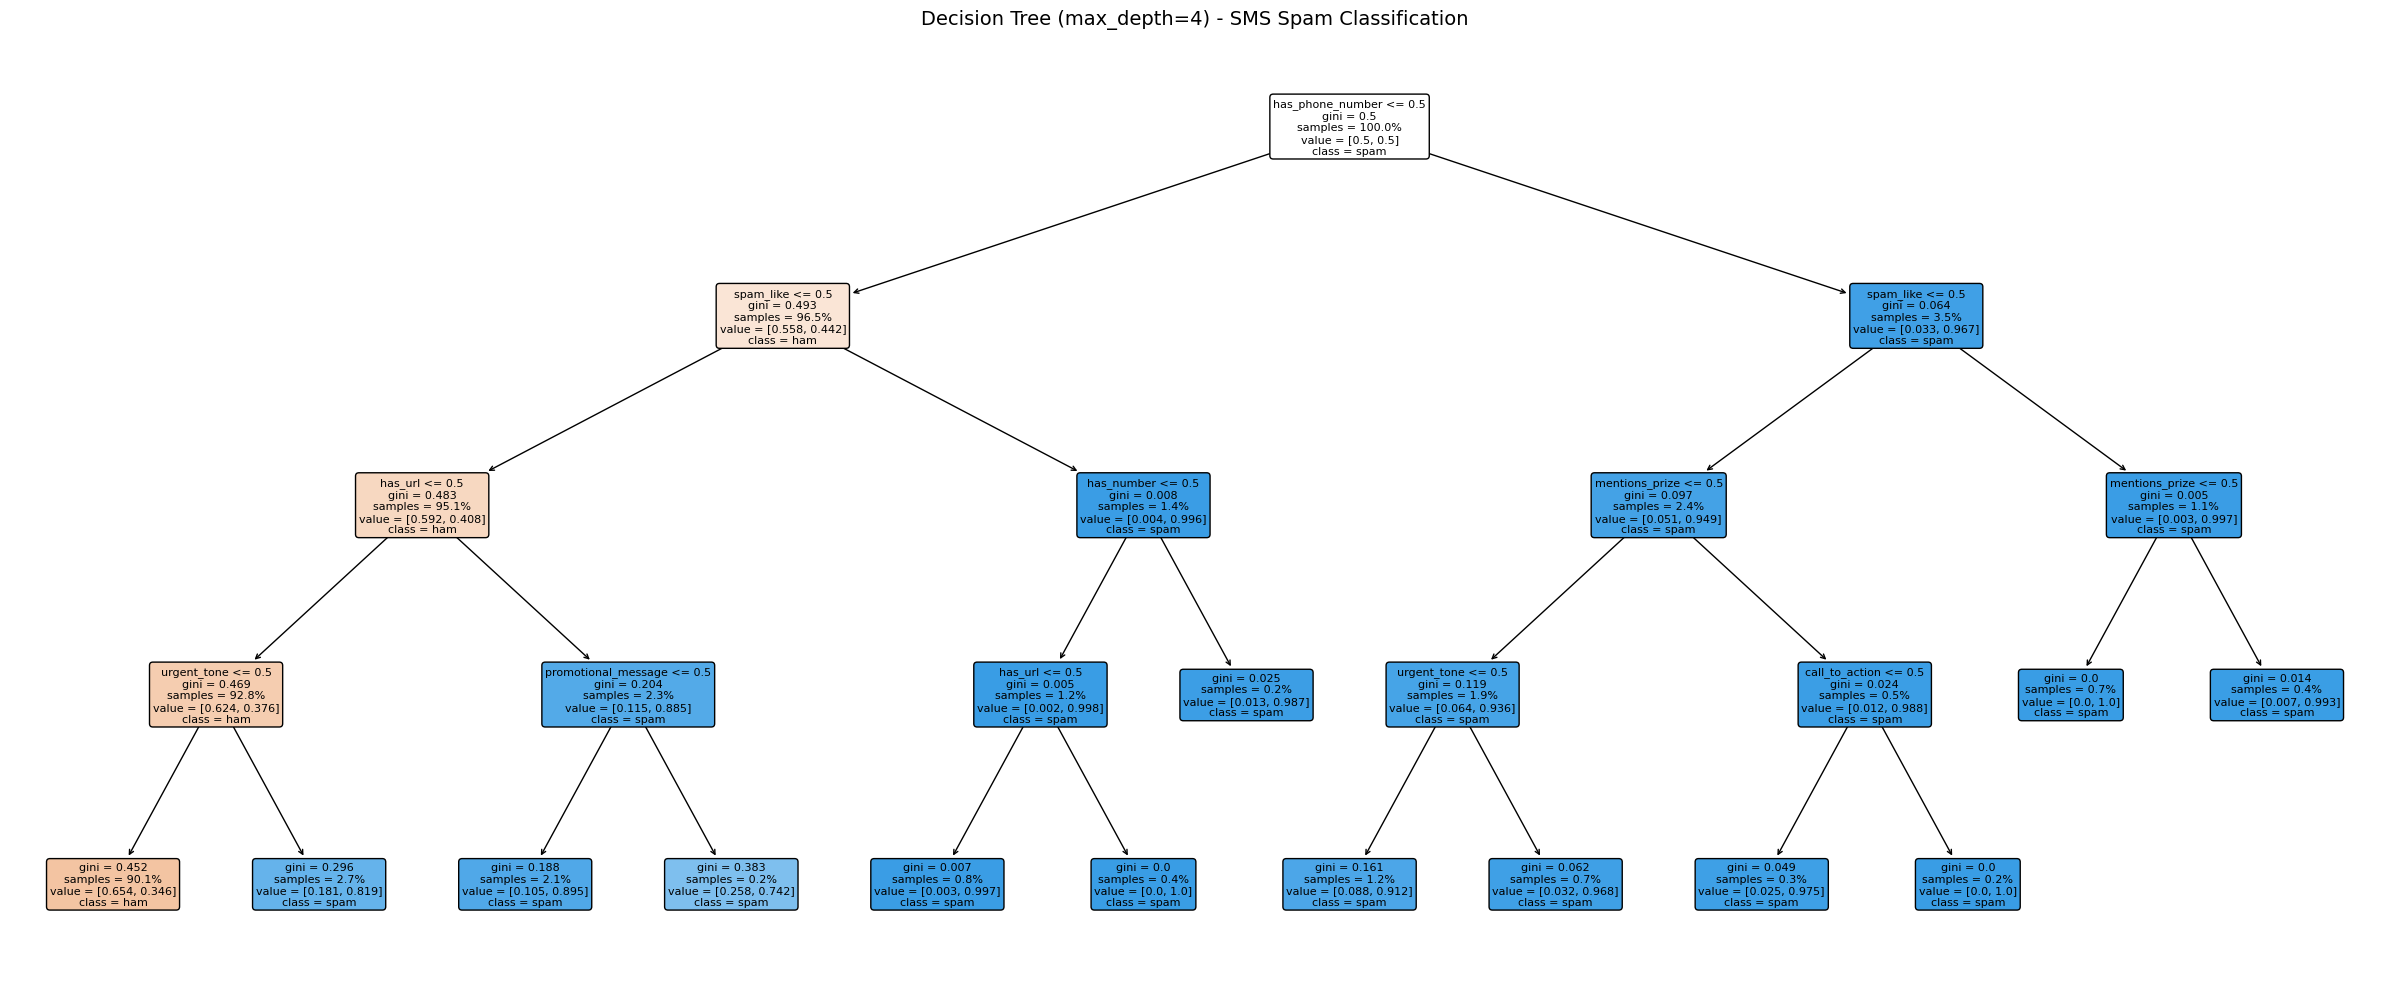

In [13]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=CLASS_NAMES,
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=8,
    impurity=True,
    proportion=True,
)
ax.set_title('Decision Tree (max_depth=4) - SMS Spam Classification', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Summary: Rules for the NSAI-HUMAINE Pipeline

In [14]:
print('=' * 70)
print('RULES FOR NSAI-HUMAINE PIPELINE')
print('=' * 70)
print()

for cls in [0, 1]:
    print(f'### {CLASS_NAMES[cls].upper()} Rules ###\n')
    for i, rule in enumerate(selected_rules[cls]):
        # Format as LTN-compatible rule
        conditions = []
        for feat, op, thresh in rule['conditions']:
            if thresh == 0.5:
                if op == '>':
                    conditions.append(f'{feat}(x)')
                else:
                    conditions.append(f'Not({feat}(x))')
            else:
                conditions.append(f'{feat}(x) {op} {thresh:.4f}')
        
        premise = ' ∧ '.join(conditions)
        conclusion = f'{CLASS_NAMES[cls]}(x)'
        
        print(f'Rule {i+1}: {premise} → {conclusion}')
        print(f'         (coverage: {rule["n_samples"]} samples, purity: {rule["purity"]:.1%})')
        print()

print('=' * 70)

RULES FOR NSAI-HUMAINE PIPELINE

### HAM Rules ###

### SPAM Rules ###



In [15]:
# Also output rules in a simpler text format for easy copy-paste
print('\n=== Simple Rule Format ===\n')
for cls in [0, 1]:
    for rule in selected_rules[cls]:
        print(format_rule(rule))


=== Simple Rule Format ===

